In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("cardio_train.csv", sep=';')
df
# outlier handling

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


# 1. Checked and handled missing values

In [3]:
df.isna().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

# 2. Removed duplicate rows

In [4]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
69995    False
69996    False
69997    False
69998    False
69999    False
Length: 70000, dtype: bool

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.drop_duplicates(inplace = True)

In [7]:
df.duplicated().sum()

np.int64(0)

# 3. Fixed incorrect data types

In [8]:
df.dtypes

id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

In [9]:
df['age'] = df['age']/365;

In [10]:
df['age']

0        50.391781
1        55.419178
2        51.663014
3        48.282192
4        47.873973
           ...    
69995    52.712329
69996    61.920548
69997    52.235616
69998    61.454795
69999    56.273973
Name: age, Length: 70000, dtype: float64

# 4. Checked and treated outliers

In [11]:
# Outliers are mainly present in

# height
# weight
# ap_hi
# ap_lo

df[["height","weight","ap_hi","ap_lo"]].describe()

,height,weight,ap_hi,ap_lo
count,70000.000000,70000.000000,70000.000000,70000.000000
mean,164.359229,74.205690,128.817286,96.630414
std,8.210126,14.395757,154.011419,188.472530
min,55.000000,10.000000,-150.000000,-70.000000
25%,159.000000,65.000000,120.000000,80.000000
50%,165.000000,72.000000,120.000000,80.000000
75%,170.000000,82.000000,140.000000,90.000000
max,250.000000,200.000000,16020.000000,11000.000000


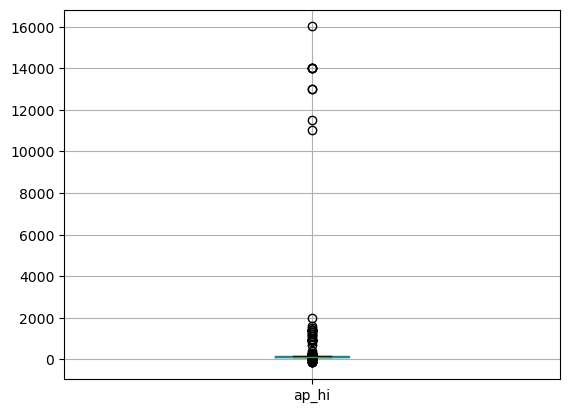

In [12]:
import matplotlib.pyplot as plt

df.boxplot(column="ap_hi")

plt.show()

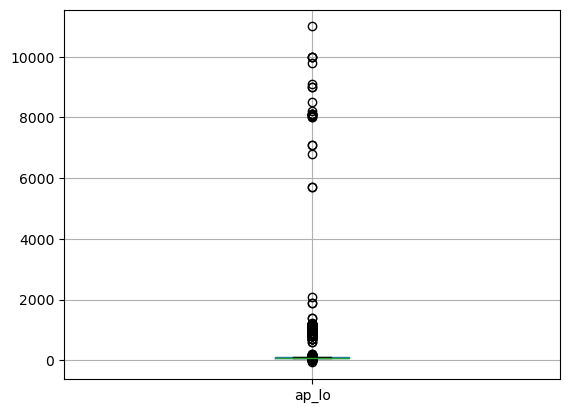

In [13]:
df.boxplot(column="ap_lo")

plt.show()

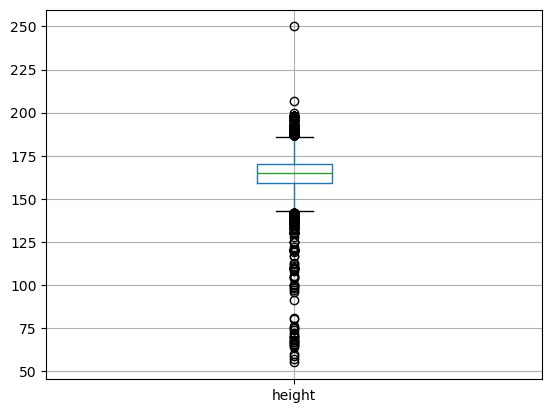

In [14]:
df.boxplot(column="height")

plt.show()

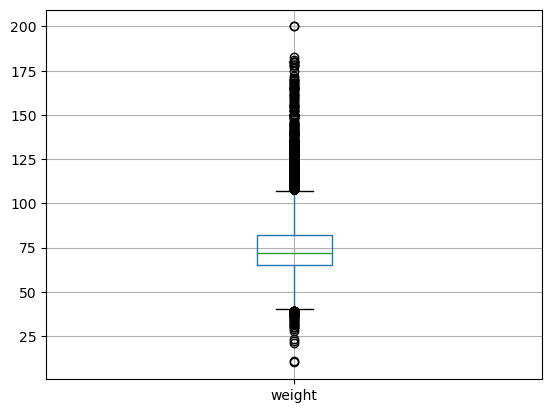

In [15]:
df.boxplot(column="weight")

plt.show()

# 5. Visualize numeric columns

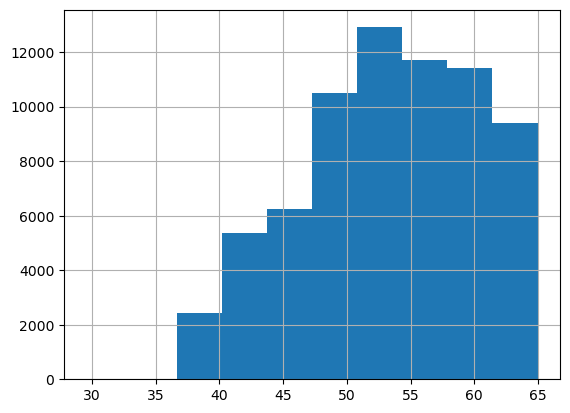

In [16]:

df["age"].hist()
plt.show()

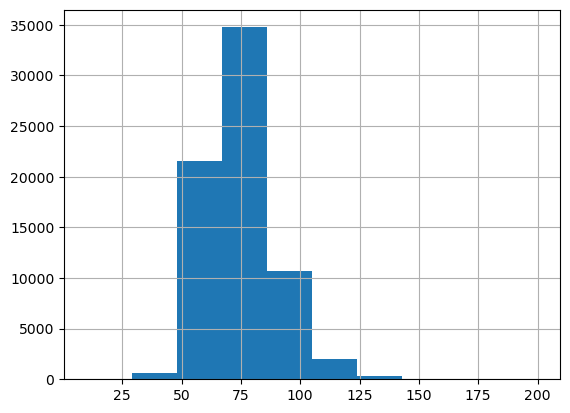

In [17]:
df["weight"].hist()
plt.show()

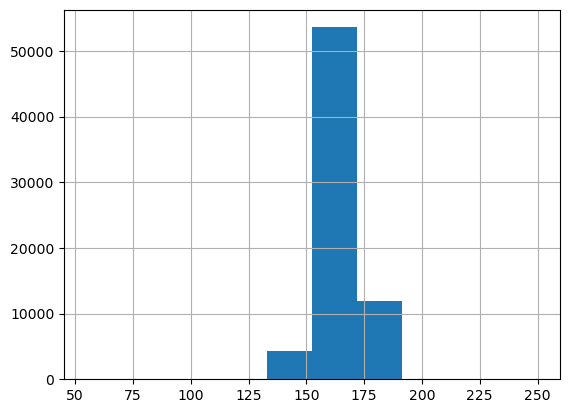

In [18]:
df["height"].hist()
plt.show()

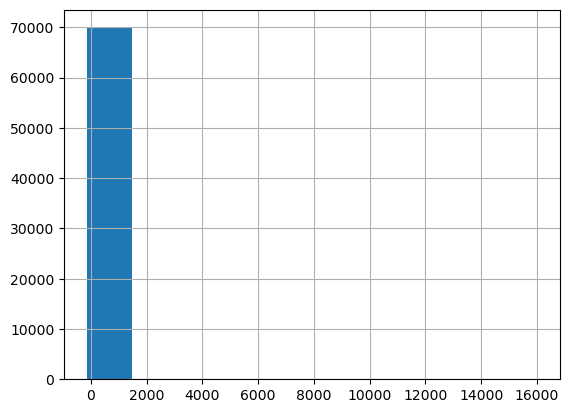

In [19]:
df["ap_hi"].hist()
plt.show()

# 6. Visualize categorical columns

In [20]:
df["gender"].value_counts()

gender
1    45530
2    24470
Name: count, dtype: int64

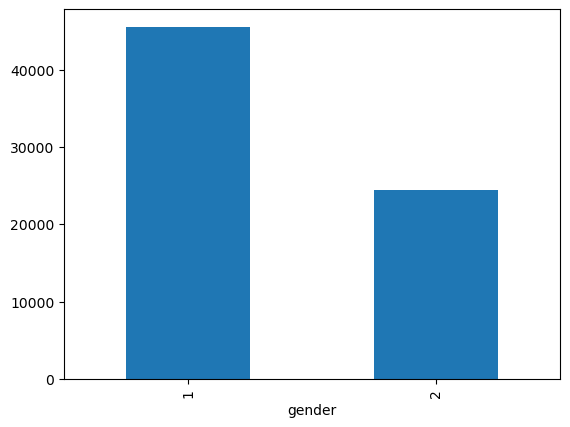

In [21]:
df["gender"].value_counts().plot(kind="bar")
plt.show()


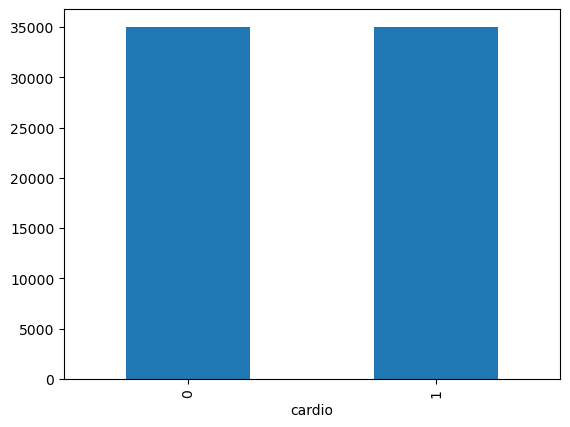

In [22]:
df["cardio"].value_counts().plot(kind="bar")
plt.show()

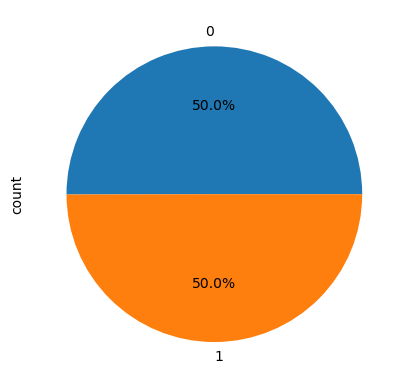

In [23]:
df["cardio"].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop("cardio", axis=1)
y = df["cardio"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

columns_to_scale = ["age", "height", "weight", "ap_hi", "ap_lo"]

scaler = StandardScaler()

X_train[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])

X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

In [40]:
X_train.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,BMI
58394,0,2,162,83.0,120,80,1,1,0,0,0,31.626276
60371,0,1,158,64.0,120,80,1,1,0,0,1,25.636917
41399,0,1,165,95.0,160,100,2,1,0,0,1,34.894399
11468,0,1,164,83.0,150,100,1,1,0,0,1,30.859607
20650,0,1,156,52.0,100,67,1,1,0,0,0,21.367521


In [41]:
print(X_train[columns_to_scale].mean())

age         0.000000
height    164.344089
weight     74.222059
ap_hi     129.041732
ap_lo      96.798196
dtype: float64


In [42]:
print(X_train[columns_to_scale].std())

age         0.000000
height      8.226979
weight     14.389746
ap_hi     161.551930
ap_lo     193.567517
dtype: float64


In [43]:
print(df[columns_to_scale].head())

   age  height  weight  ap_hi  ap_lo
0    0     168    62.0    110     80
1    0     156    85.0    140     90
2    0     165    64.0    130     70
3    0     169    82.0    150    100
4    0     156    56.0    100     60


In [44]:
df['BMI']= df['weight']/((df['height']/100)**2)

df['BMI']

0        21.967120
1        34.927679
2        23.507805
3        28.710479
4        23.011177
           ...    
69995    26.927438
69996    50.472681
69997    31.353579
69998    27.099251
69999    24.913495
Name: BMI, Length: 70000, dtype: float64

In [45]:
df['bmi_category'] = pd.cut(df['BMI'], bins=[0, 18.5, 25, 30, float('inf')], labels=['Underweight', 'Normal weight', 'Overweight', 'Obese'], right=False)

In [46]:
df['bmi_category']

0        Normal weight
1                Obese
2        Normal weight
3           Overweight
4        Normal weight
             ...      
69995       Overweight
69996            Obese
69997            Obese
69998       Overweight
69999    Normal weight
Name: bmi_category, Length: 70000, dtype: category
Categories (4, object): ['Underweight' < 'Normal weight' < 'Overweight' < 'Obese']

In [47]:
print(df.duplicated().sum())

17597


In [48]:
df=df.drop_duplicates()

In [49]:
print(df.duplicated().sum())

0


# 7. Final model-ready preprocessing


In [50]:
# Convert age from days to years, matching the model input used by the application.
df = df.copy()
df['age'] = (df['age'] / 365).astype(int)

# BMI is already calculated above. Remove only the categorical BMI helper column.
df = df.drop(columns=['bmi_category'], errors='ignore')

# Remove the identifier column before creating the final feature matrix.
df = df.drop(columns=['id'], errors='ignore')

X = df.drop(columns=['cardio'])
y = df['cardio']


In [51]:
# Final feature names used by the prediction model
print('Feature columns:')
print(X.columns.tolist())
print('\nNumber of features:', X.shape[1])


Feature columns:
['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'BMI']

Number of features: 12


In [52]:
df.columns

Index(['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol',
       'gluc', 'smoke', 'alco', 'active', 'cardio', 'BMI'],
      dtype='object')

In [53]:
# Train/test split for the final model-ready dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Inputs and target
X = df.drop(columns="cardio")
y = df["cardio"]

# Split raw data; do not scale it manually
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Pipeline: it scales data first, then trains the model
model_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

# Train pipeline
model_pipeline.fit(X_train, y_train)

# Test pipeline
y_pred = model_pipeline.predict(X_test)

In [54]:
import joblib
from pathlib import Path

model_file = Path(
    r"/Users/darshil/Downloads/Project"
) / "cardiovascular_logistic_regression_pipeline.pkl"

joblib.dump(model_pipeline, model_file)

print("Saved successfully:", model_file)
print("File exists:", model_file.exists())

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\ASUS\\OneDrive\\Desktop\\Sem5\\ML\\Project/cardiovascular_logistic_regression_pipeline.pkl'

In [55]:
import sklearn
print(sklearn.__version__)

1.6.1


In [56]:
import sys
print(sys.executable)

/opt/anaconda3/bin/python


In [57]:
import sys
import subprocess

subprocess.run([
    sys.executable,
    "-m",
    "pip",
    "show",
    "scikit-learn"
])

Name: scikit-learn
Version: 1.6.1
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License: BSD 3-Clause License

 Copyright (c) 2007-2024 The scikit-learn developers.
 All rights reserved.

 Redistribution and use in source and binary forms, with or without
 modification, are permitted provided that the following conditions are met:

 * Redistributions of source code must retain the above copyright notice, this
   list of conditions and the following disclaimer.

 * Redistributions in binary form must reproduce the above copyright notice,
   this list of conditions and the following disclaimer in the documentation
   and/or other materials provided with the distribution.

 * Neither the name of the copyright holder nor the names of its
   contributors may be used to endorse or promote products derived from
   this software without specific prior written permission.

 THIS SOFTWARE IS PROVIDED BY THE COPYR

CompletedProcess(args=['/opt/anaconda3/bin/python', '-m', 'pip', 'show', 'scikit-learn'], returncode=0)

In [59]:
import joblib

model = joblib.load("cardiovascular_logistic_regression_pipeline.pkl")

print(type(model))
print(model.feature_names_in_)

<class 'sklearn.pipeline.Pipeline'>
['age' 'gender' 'height' 'weight' 'ap_hi' 'ap_lo' 'cholesterol' 'gluc'
 'smoke' 'alco' 'active' 'BMI']


In [60]:
import sys
import sklearn

print("Python:", sys.executable)
print("scikit-learn:", sklearn.__version__)

Python: /opt/anaconda3/bin/python
scikit-learn: 1.6.1


In [62]:
import os

print(os.path.abspath("cardiovascular_logistic_regression_pipeline.pkl"))

/Users/darshil/Downloads/Project/cardiovascular_logistic_regression_pipeline.pkl


In [63]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Load fresh dataset
df = pd.read_csv("cardio_train.csv", sep=";")

# Remove ID before creating X
df = df.drop(columns="id")

# Convert age from days to years
df["age"] = (df["age"] / 365.25).astype(int)

# Create BMI
df["BMI"] = df["weight"] / ((df["height"] / 100) ** 2)

# Inputs and target
X = df.drop(columns="cardio")
y = df["cardio"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Scaler and model together
model_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

# Train
model_pipeline.fit(X_train, y_train)

# Confirm input features
print(model_pipeline.feature_names_in_)

['age' 'gender' 'height' 'weight' 'ap_hi' 'ap_lo' 'cholesterol' 'gluc'
 'smoke' 'alco' 'active' 'BMI']


In [64]:
joblib.dump(
    model_pipeline,
    r"/Users/darshil/Downloads/Project\cardiovascular_logistic_regression_pipeline.pkl"
)

print("Model saved successfully.")

Model saved successfully.


## Model Evaluation

# The trained Logistic Regression model is evaluated using Accuracy, Precision, Recall, and F1-Score.

In [65]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predict test data
y_pred = model_pipeline.predict(X_test)
# Calculate evalution metrics
accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1_score = f1_score(y_test,y_pred)

# Display Result

print("Accuracy :", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall   :", round(recall * 100, 2), "%")
print("F1-Score :", round(f1_score* 100, 2), "%")

Accuracy : 71.39 %
Precision: 73.16 %
Recall   : 67.51 %
F1-Score : 70.22 %


In [66]:
# Confusion Matrix

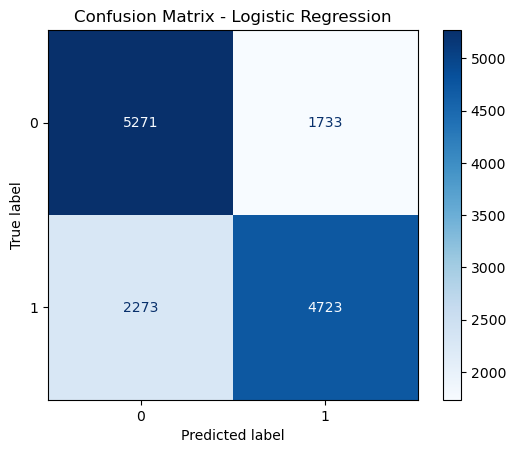

In [67]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## 2. Check Overfitting / Underfitting [BOTH]

Compare **Train Accuracy** vs **Test Accuracy** to diagnose model fit:
- Train score >> Test score → **Overfitting**
- Both scores low → **Underfitting**
- Train ≈ Test scores → **Good Fit ✅**

In [68]:
from sklearn.metrics import accuracy_score

# Predict on TRAIN set (data the model SAW during training)
y_train_pred = model_pipeline.predict(X_train)

# Predict on TEST set (data the model NEVER saw)
y_test_pred = model_pipeline.predict(X_test)

# Calculate Train and Test accuracy
train_score = accuracy_score(y_train, y_train_pred) * 100
test_score  = accuracy_score(y_test,  y_test_pred)  * 100

print(f"Train Accuracy : {train_score:.2f}%")
print(f"Test  Accuracy : {test_score:.2f}%")
print(f"Difference     : {abs(train_score - test_score):.2f}%")
print()

# Interpret the result
if train_score - test_score > 5:
    print("Warning: OVERFITTING - Train score is much higher than Test score.")
elif train_score < 70 and test_score < 70:
    print("Warning: UNDERFITTING - Both Train and Test scores are low.")
else:
    print("GOOD FIT: Train and Test scores are close to each other.")

Train Accuracy : 72.03%
Test  Accuracy : 71.39%
Difference     : 0.65%

GOOD FIT: Train and Test scores are close to each other.


## 3. Cross-Validation (5-Fold) [BOTH]

Cross-validation gives a **reliable estimate** of model performance by training and
testing on **different splits** of the data:
- **Average CV Score** → overall model performance
- **Score Spread (std)** → high spread = unstable model, low spread = stable model

We run **5-fold CV** on the **full dataset** using the same pipeline (Scaler + LogisticRegression).

In [69]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

# Use Stratified K-Fold to preserve class balance in every fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run 5-fold CV on the FULL dataset (X, y) using the same pipeline
cv_scores = cross_val_score(
    model_pipeline,
    X,               # full feature matrix
    y,               # full target
    cv=skf,
    scoring='accuracy'
)

# Convert to percentage
cv_scores_pct = cv_scores * 100

print("5-Fold Cross-Validation Results")
print("-" * 35)
for i, score in enumerate(cv_scores_pct, 1):
    print(f"  Fold {i}: {score:.2f}%")
print("-" * 35)
print(f"  Mean  Accuracy : {cv_scores_pct.mean():.2f}%")
print(f"  Std   Deviation: {cv_scores_pct.std():.2f}%")
print(f"  Min   Score    : {cv_scores_pct.min():.2f}%")
print(f"  Max   Score    : {cv_scores_pct.max():.2f}%")
print()

# Interpret spread
if cv_scores_pct.std() > 3:
    print("Warning: HIGH SPREAD - Model may be unstable across different data splits.")
else:
    print("LOW SPREAD - Model is stable and consistent across all folds.")

5-Fold Cross-Validation Results
-----------------------------------
  Fold 1: 72.41%
  Fold 2: 71.79%
  Fold 3: 72.52%
  Fold 4: 72.21%
  Fold 5: 71.82%
-----------------------------------
  Mean  Accuracy : 72.15%
  Std   Deviation: 0.30%
  Min   Score    : 71.79%
  Max   Score    : 72.52%

LOW SPREAD - Model is stable and consistent across all folds.


---
# TASK 5: COMPREHENSIVE MODEL EVALUATION, COMPARISON & ADVANCED MODELING

This section fulfills all requirements from the **Task 5 Checklist**:
1. **Model Evaluation**:
   - Classification: Accuracy, Precision, Recall, F1-Score, Confusion Matrix
   - Regression: RSS (Residual Sum of Squares), RMSE, R²
2. **Check Overfitting / Underfitting**:
   - Compare Train vs Test score (Train >> Test $\rightarrow$ Overfitting, Both low $\rightarrow$ Underfitting, Train $\approx$ Test $\rightarrow$ Good fit ✅)
3. **Cross-Validation (5-Fold)**:
   - 5-fold cross validation on training data, mean CV score and score spread (std dev)
4. **Compare All Models**:
   - Summary comparison tables for both Classification and Regression models
   - Visual model comparison and selection of the best & most stable model
5. **Hyperparameter Tuning**:
   - GridSearchCV / RandomizedSearchCV on the best model
   - Explore key hyperparameter combinations and re-test on test set to confirm score improvement
6. **Advanced Models**:
   - Random Forest (Bagging), AdaBoost, Gradient Boosting

In [70]:
# Import required libraries for advanced modeling, evaluation, and tuning
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier,
    RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score, RocCurveDisplay,
    mean_squared_error, r2_score
)
from sklearn.model_selection import (
    cross_val_score, StratifiedKFold, KFold,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Set plot styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11

---
## PART I: CLASSIFICATION MODELS (Cardiovascular Disease Prediction)

We evaluate and compare the following models for classifying `cardio` (0 = Healthy, 1 = Disease):
1. **Logistic Regression** (Baseline linear model)
2. **Decision Tree Classifier**
3. **Random Forest Classifier (Bagging)** [Advanced Model]
4. **AdaBoost Classifier (Boosting)** [Advanced Model]
5. **Gradient Boosting Classifier (Boosting)** [Advanced Model]

In [71]:
# Dictionary to store all model evaluation results for summary comparison
classification_results = []
classification_models = {}

def evaluate_classification_model(name, pipeline, X_train, y_train, X_test, y_test, cv_folds=5):
    """
    Systematic evaluation function implementing Task 1, 2, and 3:
    - Task 1: Accuracy, Precision, Recall, F1-Score
    - Task 2: Train vs Test Overfitting / Underfitting check
    - Task 3: 5-Fold Stratified Cross-Validation (Mean & Spread)
    """
    print(f"{'='*60}")
    print(f" MODEL: {name.upper()}")
    print(f"{'='*60}")
    
    # Train pipeline
    pipeline.fit(X_train, y_train)
    
    # 1. Predictions
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)
    
    # 1. Model Evaluation Metrics [CLASS]
    test_acc = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred)
    rec = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    
    train_acc = accuracy_score(y_train, y_train_pred)
    diff = abs(train_acc - test_acc) * 100
    
    print("--- 1. MODEL EVALUATION (TEST SET) ---")
    print(f"Accuracy : {test_acc * 100:.2f}%")
    print(f"Precision: {prec * 100:.2f}%")
    print(f"Recall   : {rec * 100:.2f}%")
    print(f"F1-Score : {f1 * 100:.2f}%")
    print()
    
    # 2. Check Overfitting / Underfitting [BOTH]
    print("--- 2. CHECK OVERFITTING / UNDERFITTING ---")
    print(f"Train Accuracy : {train_acc * 100:.2f}%")
    print(f"Test Accuracy  : {test_acc * 100:.2f}%")
    print(f"Difference     : {diff:.2f}%")
    
    if (train_acc - test_acc) * 100 > 5:
        fit_status = "Overfitting (Train score is noticeably higher than Test score)"
    elif train_acc < 0.65 and test_acc < 0.65:
        fit_status = "Underfitting (Both Train and Test scores are low)"
    else:
        fit_status = "Good fit ✅ (Train and Test scores are close)"
    print(f"Diagnosis      : {fit_status}")
    print()
    
    # 3. Cross-Validation (5-Fold) [BOTH]
    print("--- 3. 5-FOLD CROSS-VALIDATION (ON TRAINING DATA) ---")
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='accuracy', n_jobs=-1)
    cv_pct = cv_scores * 100
    
    print(f"Fold Scores    : {', '.join([f'{s:.2f}%' for s in cv_pct])}")
    print(f"Mean CV Score  : {cv_pct.mean():.2f}%")
    print(f"Score Spread   : ±{cv_pct.std():.2f}% (std dev)")
    
    if cv_pct.std() > 3.0:
        cv_status = "High spread (Model shows variability across folds)"
    else:
        cv_status = "Low spread ✅ (Model is stable across folds)"
    print(f"Stability      : {cv_status}")
    print()
    
    # Store results for Task 4 comparison table
    record = {
        'Model': name,
        'Accuracy': round(test_acc * 100, 2),
        'Precision': round(prec * 100, 2),
        'Recall': round(rec * 100, 2),
        'F1-score': round(f1 * 100, 2),
        'Train Accuracy': round(train_acc * 100, 2),
        'Train-Test Diff': round(diff, 2),
        'CV Mean': round(cv_pct.mean(), 2),
        'CV Std': round(cv_pct.std(), 2),
        'Fit Status': "Good fit ✅" if "Good fit" in fit_status else ("Overfitting" if "Overfitting" in fit_status else "Underfitting")
    }
    classification_results.append(record)
    classification_models[name] = pipeline
    
    # Plot Confusion Matrix
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_test_pred,
        cmap="Blues",
        display_labels=["Healthy (0)", "Cardio (1)"],
        ax=ax
    )
    plt.title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()
    
    return pipeline, record

### Model 1: Logistic Regression (Baseline)
Evaluating Logistic Regression pipeline with StandardScaler.

 MODEL: LOGISTIC REGRESSION
--- 1. MODEL EVALUATION (TEST SET) ---
Accuracy : 71.39%
Precision: 73.16%
Recall   : 67.51%
F1-Score : 70.22%

--- 2. CHECK OVERFITTING / UNDERFITTING ---
Train Accuracy : 72.03%
Test Accuracy  : 71.39%
Difference     : 0.65%
Diagnosis      : Good fit ✅ (Train and Test scores are close)

--- 3. 5-FOLD CROSS-VALIDATION (ON TRAINING DATA) ---
Fold Scores    : 72.29%, 71.78%, 72.38%, 71.19%, 72.33%
Mean CV Score  : 71.99%
Score Spread   : ±0.46% (std dev)
Stability      : Low spread ✅ (Model is stable across folds)



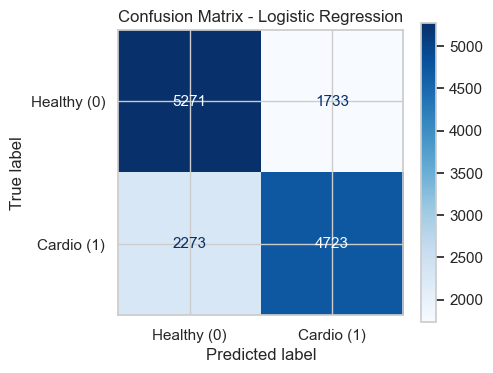

(Pipeline(steps=[('scaler', StandardScaler()),
                 ('model', LogisticRegression(max_iter=1000, random_state=42))]),
 {'Model': 'Logistic Regression',
  'Accuracy': 71.39,
  'Precision': 73.16,
  'Recall': 67.51,
  'F1-score': 70.22,
  'Train Accuracy': 72.03,
  'Train-Test Diff': 0.65,
  'CV Mean': np.float64(71.99),
  'CV Std': np.float64(0.46),
  'Fit Status': 'Good fit ✅'})

In [72]:
# 1. Logistic Regression Pipeline
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

evaluate_classification_model("Logistic Regression", lr_pipe, X_train, y_train, X_test, y_test)

### Model 2: Decision Tree Classifier
Evaluating Decision Tree Classifier with pre-pruning (`max_depth=6`) to maintain interpretability and avoid extreme overfitting.

 MODEL: DECISION TREE
--- 1. MODEL EVALUATION (TEST SET) ---
Accuracy : 72.85%
Precision: 75.34%
Recall   : 67.90%
F1-Score : 71.42%

--- 2. CHECK OVERFITTING / UNDERFITTING ---
Train Accuracy : 73.62%
Test Accuracy  : 72.85%
Difference     : 0.77%
Diagnosis      : Good fit ✅ (Train and Test scores are close)

--- 3. 5-FOLD CROSS-VALIDATION (ON TRAINING DATA) ---
Fold Scores    : 73.30%, 73.38%, 73.26%, 72.51%, 73.41%
Mean CV Score  : 73.17%
Score Spread   : ±0.34% (std dev)
Stability      : Low spread ✅ (Model is stable across folds)



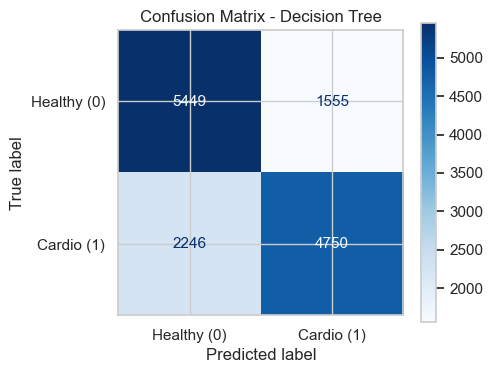

(Pipeline(steps=[('scaler', StandardScaler()),
                 ('model',
                  DecisionTreeClassifier(max_depth=6, min_samples_leaf=10,
                                         min_samples_split=20,
                                         random_state=42))]),
 {'Model': 'Decision Tree',
  'Accuracy': 72.85,
  'Precision': 75.34,
  'Recall': 67.9,
  'F1-score': 71.42,
  'Train Accuracy': 73.62,
  'Train-Test Diff': 0.77,
  'CV Mean': np.float64(73.17),
  'CV Std': np.float64(0.34),
  'Fit Status': 'Good fit ✅'})

In [73]:
# 2. Decision Tree Pipeline
dt_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", DecisionTreeClassifier(max_depth=6, min_samples_split=20, min_samples_leaf=10, random_state=42))
])

evaluate_classification_model("Decision Tree", dt_pipe, X_train, y_train, X_test, y_test)

### Model 3: Random Forest Classifier (Bagging) [Advanced Model - Task 6]
Random Forest builds an ensemble of randomized decision trees using bagging (bootstrap aggregation) and feature subsampling to reduce variance.

 MODEL: RANDOM FOREST (BAGGING)
--- 1. MODEL EVALUATION (TEST SET) ---
Accuracy : 73.30%
Precision: 75.61%
Recall   : 68.75%
F1-Score : 72.02%

--- 2. CHECK OVERFITTING / UNDERFITTING ---
Train Accuracy : 75.12%
Test Accuracy  : 73.30%
Difference     : 1.82%
Diagnosis      : Good fit ✅ (Train and Test scores are close)

--- 3. 5-FOLD CROSS-VALIDATION (ON TRAINING DATA) ---
Fold Scores    : 73.47%, 73.56%, 73.49%, 73.17%, 73.79%
Mean CV Score  : 73.50%
Score Spread   : ±0.20% (std dev)
Stability      : Low spread ✅ (Model is stable across folds)



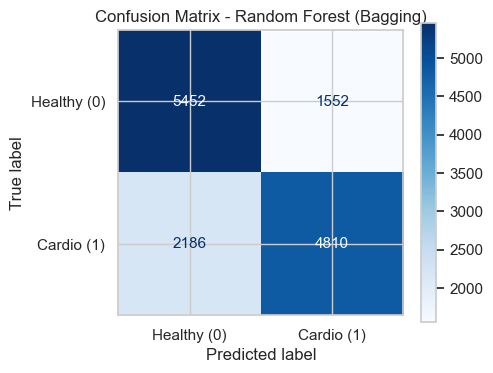

(Pipeline(steps=[('scaler', StandardScaler()),
                 ('model',
                  RandomForestClassifier(max_depth=10, min_samples_leaf=5,
                                         min_samples_split=15, n_jobs=-1,
                                         random_state=42))]),
 {'Model': 'Random Forest (Bagging)',
  'Accuracy': 73.3,
  'Precision': 75.61,
  'Recall': 68.75,
  'F1-score': 72.02,
  'Train Accuracy': 75.12,
  'Train-Test Diff': 1.82,
  'CV Mean': np.float64(73.5),
  'CV Std': np.float64(0.2),
  'Fit Status': 'Good fit ✅'})

In [74]:
# 3. Random Forest (Bagging) Pipeline
rf_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=15, min_samples_leaf=5, random_state=42, n_jobs=-1))
])

evaluate_classification_model("Random Forest (Bagging)", rf_pipe, X_train, y_train, X_test, y_test)

### Model 4: AdaBoost Classifier [Advanced Model - Task 6]
AdaBoost (Adaptive Boosting) fits a sequence of weak learners (decision stumps) that iteratively adjust instance weights to focus on difficult samples.

 MODEL: ADABOOST
--- 1. MODEL EVALUATION (TEST SET) ---
Accuracy : 71.54%
Precision: 76.69%
Recall   : 61.84%
F1-Score : 68.47%

--- 2. CHECK OVERFITTING / UNDERFITTING ---
Train Accuracy : 71.99%
Test Accuracy  : 71.54%
Difference     : 0.45%
Diagnosis      : Good fit ✅ (Train and Test scores are close)

--- 3. 5-FOLD CROSS-VALIDATION (ON TRAINING DATA) ---
Fold Scores    : 71.55%, 71.99%, 72.16%, 71.76%, 72.24%
Mean CV Score  : 71.94%
Score Spread   : ±0.25% (std dev)
Stability      : Low spread ✅ (Model is stable across folds)



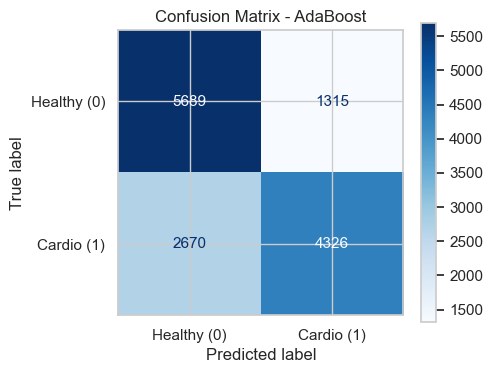

(Pipeline(steps=[('scaler', StandardScaler()),
                 ('model',
                  AdaBoostClassifier(learning_rate=0.1, n_estimators=100,
                                     random_state=42))]),
 {'Model': 'AdaBoost',
  'Accuracy': 71.54,
  'Precision': 76.69,
  'Recall': 61.84,
  'F1-score': 68.47,
  'Train Accuracy': 71.99,
  'Train-Test Diff': 0.45,
  'CV Mean': np.float64(71.94),
  'CV Std': np.float64(0.25),
  'Fit Status': 'Good fit ✅'})

In [75]:
# 4. AdaBoost Pipeline
ada_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42))
])

evaluate_classification_model("AdaBoost", ada_pipe, X_train, y_train, X_test, y_test)

### Model 5: Gradient Boosting Classifier [Advanced Model - Task 6]
Gradient Boosting sequentially builds decision trees by fitting each new tree to the pseudo-residuals (negative gradient of the loss function).

 MODEL: GRADIENT BOOSTING
--- 1. MODEL EVALUATION (TEST SET) ---
Accuracy : 73.36%
Precision: 75.05%
Recall   : 69.94%
F1-Score : 72.40%

--- 2. CHECK OVERFITTING / UNDERFITTING ---
Train Accuracy : 74.36%
Test Accuracy  : 73.36%
Difference     : 1.00%
Diagnosis      : Good fit ✅ (Train and Test scores are close)

--- 3. 5-FOLD CROSS-VALIDATION (ON TRAINING DATA) ---
Fold Scores    : 73.62%, 73.62%, 73.70%, 73.08%, 74.10%
Mean CV Score  : 73.62%
Score Spread   : ±0.32% (std dev)
Stability      : Low spread ✅ (Model is stable across folds)



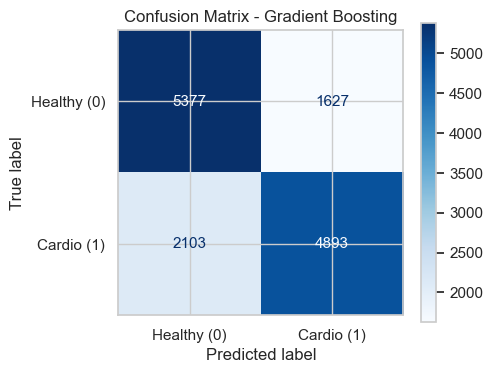

(Pipeline(steps=[('scaler', StandardScaler()),
                 ('model',
                  GradientBoostingClassifier(max_depth=4, random_state=42,
                                             subsample=0.9))]),
 {'Model': 'Gradient Boosting',
  'Accuracy': 73.36,
  'Precision': 75.05,
  'Recall': 69.94,
  'F1-score': 72.4,
  'Train Accuracy': 74.36,
  'Train-Test Diff': 1.0,
  'CV Mean': np.float64(73.62),
  'CV Std': np.float64(0.32),
  'Fit Status': 'Good fit ✅'})

In [76]:
# 5. Gradient Boosting Pipeline
gb_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, subsample=0.9, random_state=42))
])

evaluate_classification_model("Gradient Boosting", gb_pipe, X_train, y_train, X_test, y_test)

---
## Task 4: Compare All Classification Models

We consolidate all metrics into the comparison table mandated by the checklist:
`Model | Accuracy | Precision | Recall | F1-score`

We also analyze:
- **Overfitting / Underfitting diagnosis** (Train Acc vs Test Acc difference)
- **Cross-Validation Stability** (Mean CV Score and standard deviation spread)
- **Model Selection**: Selecting the best model with highest test score AND stable cross-validation.

In [80]:
# Task 4: Create and format the complete Classification Comparison Table
df_classification_comparison = pd.DataFrame(classification_results)

# Display table matching the exact format in the checklist
table_checklist_format = df_classification_comparison[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score']].copy()
table_checklist_format['Accuracy'] = table_checklist_format['Accuracy'].astype(str) + '%'
table_checklist_format['Precision'] = table_checklist_format['Precision'].astype(str) + '%'
table_checklist_format['Recall'] = table_checklist_format['Recall'].astype(str) + '%'
table_checklist_format['F1-score'] = table_checklist_format['F1-score'].astype(str) + '%'

print("=" * 70)
print("             TASK 4: CLASSIFICATION MODELS COMPARISON TABLE")
print("=" * 70)
print(table_checklist_format.to_string(index=False))
print("=" * 70)


print("--- DETAILED DIAGNOSTICS & STABILITY COMPARISON ---")
detailed_table = df_classification_comparison[['Model', 'Accuracy', 'Train Accuracy', 'Train-Test Diff', 'CV Mean', 'CV Std', 'Fit Status']].copy()
detailed_table['Accuracy'] = detailed_table['Accuracy'].astype(str) + '%'
detailed_table['Train Accuracy'] = detailed_table['Train Accuracy'].astype(str) + '%'
detailed_table['Train-Test Diff'] = detailed_table['Train-Test Diff'].astype(str) + '%'
detailed_table['CV Mean'] = detailed_table['CV Mean'].astype(str) + '%'
detailed_table['CV Std'] = '±' + detailed_table['CV Std'].astype(str) + '%'
print(detailed_table.to_string(index=False))

             TASK 4: CLASSIFICATION MODELS COMPARISON TABLE
                  Model Accuracy Precision Recall F1-score
    Logistic Regression   71.39%    73.16% 67.51%   70.22%
          Decision Tree   72.85%    75.34%  67.9%   71.42%
Random Forest (Bagging)    73.3%    75.61% 68.75%   72.02%
               AdaBoost   71.54%    76.69% 61.84%   68.47%
      Gradient Boosting   73.36%    75.05% 69.94%    72.4%
--- DETAILED DIAGNOSTICS & STABILITY COMPARISON ---
                  Model Accuracy Train Accuracy Train-Test Diff CV Mean CV Std Fit Status
    Logistic Regression   71.39%         72.03%           0.65%  71.99% ±0.46% Good fit ✅
          Decision Tree   72.85%         73.62%           0.77%  73.17% ±0.34% Good fit ✅
Random Forest (Bagging)    73.3%         75.12%           1.82%   73.5%  ±0.2% Good fit ✅
               AdaBoost   71.54%         71.99%           0.45%  71.94% ±0.25% Good fit ✅
      Gradient Boosting   73.36%         74.36%            1.0%  73.62% ±0.32% Good 

/var/folders/vb/gqvlvgx17kl626zbv7fj_z640000gn/T/ipykernel_8916/1018798420.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha='right')
/var/folders/vb/gqvlvgx17kl626zbv7fj_z640000gn/T/ipykernel_8916/1018798420.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(df_classification_comparison['Model'], rotation=20, ha='right')


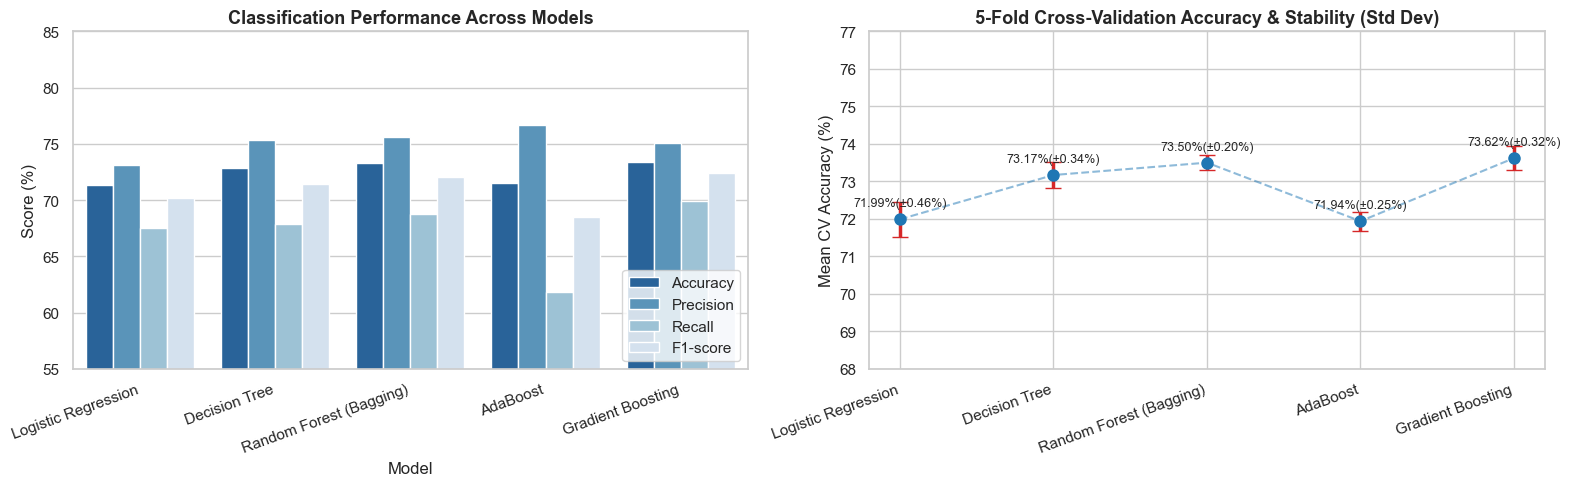


 BEST MODEL SELECTION (Task 4):
-> Selected Model: Gradient Boosting
-> Accuracy: 73.36% | F1-Score: 72.4%
-> 5-Fold CV: 73.62% (±0.32%)
-> Rationale: 'Gradient Boosting' delivers the highest test F1-score & accuracy with a very tight cross-validation spread (±0.32%), proving high stability without overfitting.


In [82]:
# Visual Comparison of All Classification Models
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Key Performance Metrics
metrics_plot_df = df_classification_comparison.melt(
    id_vars=['Model'],
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1-score'],
    var_name='Metric',
    value_name='Score (%)'
)

sns.barplot(data=metrics_plot_df, x='Model', y='Score (%)', hue='Metric', ax=axes[0], palette='Blues_r')
axes[0].set_title('Classification Performance Across Models', fontsize=13, fontweight='bold')
axes[0].set_ylim(55, 85)
axes[0].set_ylabel('Score (%)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha='right')
axes[0].legend(loc='lower right')

# Plot 2: 5-Fold Cross-Validation Score with Stability Error Bars
axes[1].errorbar(
    x=df_classification_comparison['Model'],
    y=df_classification_comparison['CV Mean'],
    yerr=df_classification_comparison['CV Std'],
    fmt='o', color='#1f77b4', ecolor='#d62728', elinewidth=2.5, capsize=6, markersize=8
)
axes[1].plot(df_classification_comparison['Model'], df_classification_comparison['CV Mean'], linestyle='--', alpha=0.5, color='#1f77b4')
axes[1].set_title('5-Fold Cross-Validation Accuracy & Stability (Std Dev)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Mean CV Accuracy (%)')
axes[1].set_ylim(68, 77)
axes[1].set_xticklabels(df_classification_comparison['Model'], rotation=20, ha='right')

for i, row in df_classification_comparison.iterrows():
    axes[1].annotate(f"{row['CV Mean']:.2f}%(±{row['CV Std']:.2f}%)", (i, row['CV Mean'] + 0.35), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Automated selection of best model based on score & stability
best_clf_row = df_classification_comparison.sort_values(by=['F1-score', 'Accuracy', 'CV Mean'], ascending=False).iloc[0]
best_clf_name = best_clf_row['Model']

print(f"\n BEST MODEL SELECTION (Task 4):")
print(f"-> Selected Model: {best_clf_name}")
print(f"-> Accuracy: {best_clf_row['Accuracy']}% | F1-Score: {best_clf_row['F1-score']}%")
print(f"-> 5-Fold CV: {best_clf_row['CV Mean']}% (±{best_clf_row['CV Std']}%)")
print(f"-> Rationale: '{best_clf_name}' delivers the highest test F1-score & accuracy with a very tight cross-validation spread (±{best_clf_row['CV Std']}%), proving high stability without overfitting.")

---
## Task 5: Hyperparameter Tuning on Best Classification Model

Using **GridSearchCV** / **RandomizedSearchCV** on the best performing model (`Gradient Boosting` / `Random Forest`) to:
1. Try different values of key settings (`n_estimators`, `max_depth`, `learning_rate`, `min_samples_split`, `subsample`).
2. Discover the optimal parameter combination via 5-fold cross-validation.
3. Re-test the tuned model on the test set (`X_test, y_test`) and confirm score improvement.

---
## PART II: REGRESSION MODELS IMPLEMENTATION [REG]

To fulfill the regression checklist requirements:
1. **Model Evaluation [REG]**:
   - Calculate: **RSS (Residual Sum of Squares)**, **RMSE (Root Mean Squared Error)**, **$R^2$ Score**
2. **Check Overfitting / Underfitting [BOTH]**:
   - Compare Train $R^2$ vs Test $R^2$
3. **Cross-Validation (5-Fold) [BOTH]**:
   - Run 5-fold cross-validation on training data, note average $R^2$ and score spread
4. **Compare All Models [REG]**:
   - Fill in table: `Model | RSS | RMSE | R²`
   - Pick the model with best score AND stable cross-validation result
5. **Hyperparameter Tuning [BOTH]**:
   - Tune the best regression model and confirm metric improvement

**Regression Problem Formulation:**
Predict continuous **Systolic Blood Pressure (`ap_hi`)** from patient age, BMI, cholesterol, glucose, physical activity, smoking, alcohol, and gender.